<a href="https://colab.research.google.com/github/dheaadventina/Hands-On-Projek-ETS-Matematika-Aktuaria_Dhea-Adventina-Sandy/blob/main/Hands_On_Proyek_ETS_Matematika_Aktuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving heart_failure_clinical_records_dataset.csv to heart_failure_clinical_records_dataset (10).csv

=== DATA AWAL ===
    age  time  DEATH_EVENT
0  75.0     4            1
1  55.0     6            1
2  65.0     7            1
3  50.0     7            1
4  65.0     8            1

=== STATISTIK DESKRIPTIF ===
              age        time
count  299.000000  299.000000
mean    60.833893  130.260870
std     11.894809   77.614208
min     40.000000    4.000000
25%     51.000000   73.000000
50%     60.000000  115.000000
75%     70.000000  203.000000
max     95.000000  285.000000

=== DISTRIBUSI DEATH_EVENT ===
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

=== PERSENTASE DEATH_EVENT ===
DEATH_EVENT
0    67.892977
1    32.107023
Name: proportion, dtype: float64

=== TABEL SURVIVAL ===
          KM_estimate
timeline             
0.0          1.000000
4.0          0.996656
6.0          0.993311
7.0          0.986622
8.0          0.979933

Median survival time: inf


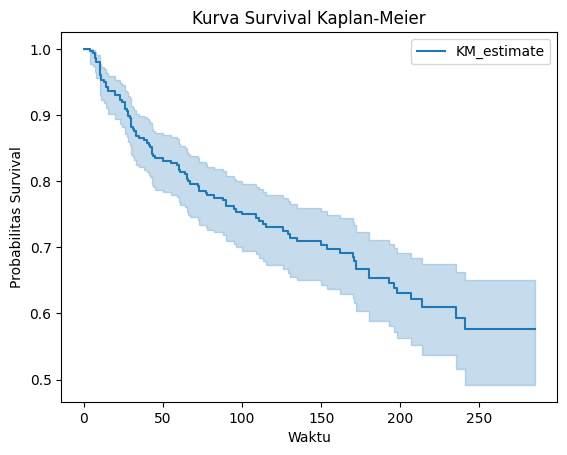


=== COX PH ===


<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -497.45
         time fit was run = 2026-04-03 13:55:14 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.04      1.04      0.01            0.03            0.06                1.03                1.06

           cmp to    z      p  -log2(p)
covariate                              
age          0.00 4.93 <0.005     20.19
---
Concordance = 0.63
Partial AIC = 996.90
log-likelihood ratio test = 23.52 on 1 df
-log2(p) of ll-ratio test = 19.62

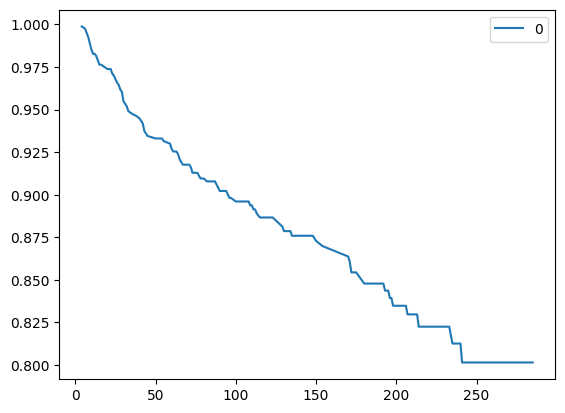

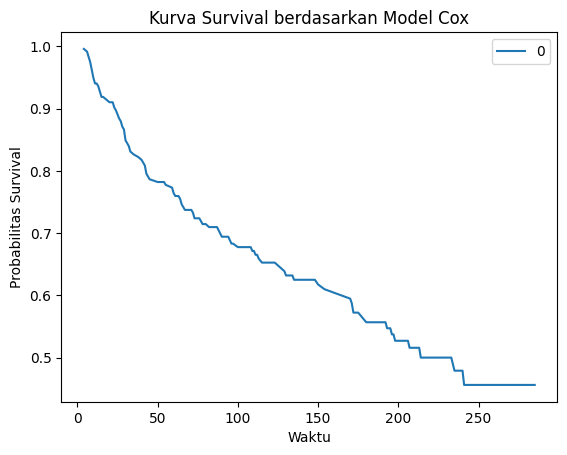


=== WEIBULL ===


<lifelines.WeibullAFTFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
   number of observations = 299
number of events observed = 96
           log-likelihood = -658.22
         time fit was run = 2026-04-03 13:55:14 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ age       -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
        Intercept  9.25  10353.29      0.73            7.82           10.67             2491.08            43029.80
rho_    Intercept -0.14      0.87      0.09           -0.32            0.04                0.73                1.04

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ age          0.00 -4.76 <0.005     19.00
        Intercept    0.00 12.72 <0.005    120.71
rho_    Intercept    0.00 -1.56   0.12      3.07
---
Concordance = 0.63
AIC = 1322.44
log-likelihood ratio test = 24.44 on 1 df
-log2(p) of ll-ratio test = 20.31

<Figure size 640x480 with 0 Axes>

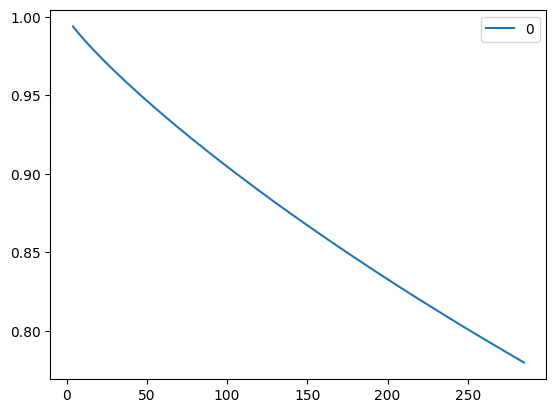

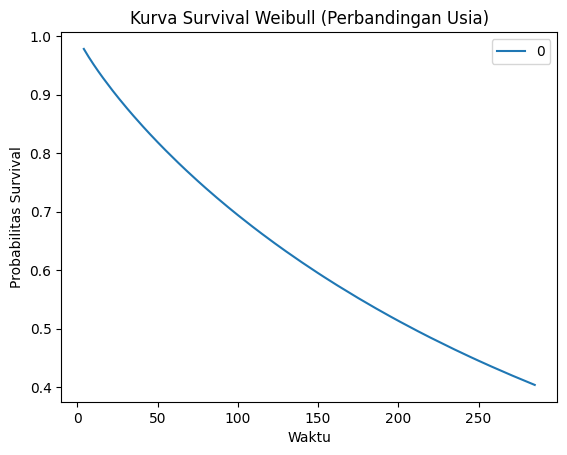


=== TABEL MORTALITAS ===
   age  lx  dx        qx        px    Lx     Tx          ex
0   40   7   0  0.000000  1.000000   4.0  294.5   42.071429
1   41   1   0  0.000000  1.000000   4.0  290.5  290.500000
2   42   7   1  0.142857  0.857143   4.0  286.5   40.928571
3   43   1   0  0.000000  1.000000   1.5  282.5  282.500000
4   44   2   0  0.000000  1.000000  10.5  281.0  140.500000
5   45  19   6  0.315789  0.684211  11.0  270.5   14.236842
6   46   3   1  0.333333  0.666667   2.0  259.5   86.500000
7   47   1   0  0.000000  1.000000   1.5  257.5  257.500000
8   48   2   2  1.000000  0.000000   3.0  256.0  128.000000
9   49   4   1  0.250000  0.750000  15.5  253.0   63.250000

=== HARAPAN HIDUP BEBERAPA USIA ===
e_40 = 42.07 tahun
e_50 = 8.80 tahun
e_60 = 4.62 tahun
e_70 = 2.54 tahun
e_80 = 2.93 tahun
e_90 = 1.17 tahun


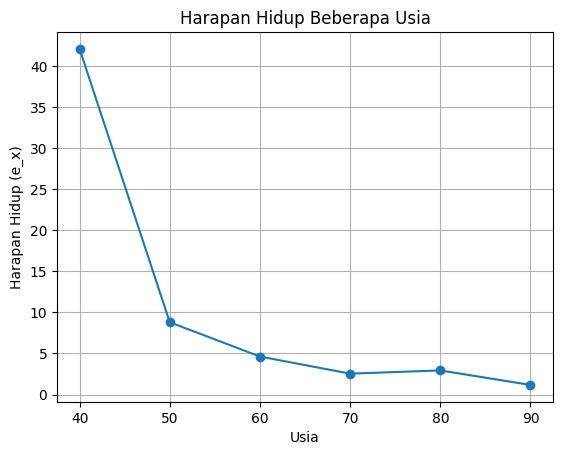

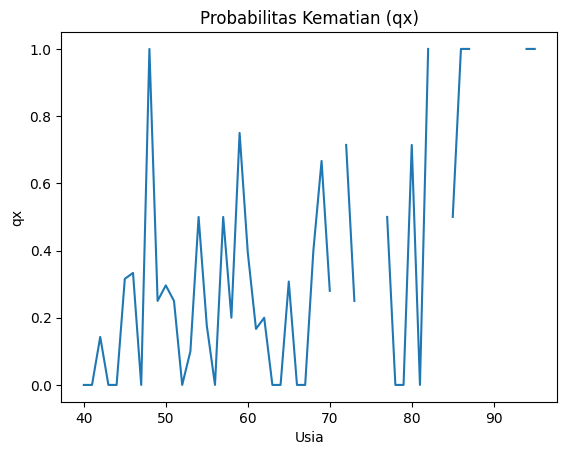

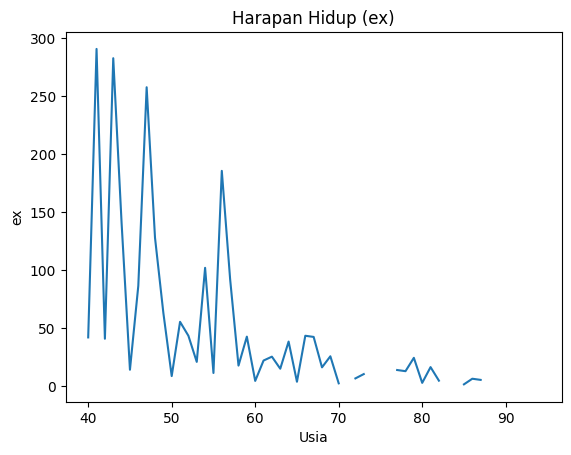

In [12]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

!pip install lifelines
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, WeibullAFTFitter

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
print("\n=== DATA AWAL ===")
print(df[['age', 'time', 'DEATH_EVENT']].head())

# =========================
# CLEAN DATA
# =========================
df = df[['age', 'time', 'DEATH_EVENT']].dropna()

# =========================
# STATISTIK DESKRIPTIF
# =========================

print("\n=== STATISTIK DESKRIPTIF ===")

# statistik untuk variabel numerik
desc = df[['age', 'time']].describe()
print(desc)

# distribusi kejadian
print("\n=== DISTRIBUSI DEATH_EVENT ===")
death_dist = df['DEATH_EVENT'].value_counts()
print(death_dist)

# persentase
print("\n=== PERSENTASE DEATH_EVENT ===")
death_percent = df['DEATH_EVENT'].value_counts(normalize=True) * 100
print(death_percent)

# =========================
# KAPLAN-MEIER
# =========================
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(df['time'], event_observed=df['DEATH_EVENT'])
print("\n=== TABEL SURVIVAL ===")
print(kmf.survival_function_.head())

print("\nMedian survival time:", kmf.median_survival_time_)

plt.figure()
kmf.plot()
plt.title("Kurva Survival Kaplan-Meier")
plt.xlabel("Waktu")
plt.ylabel("Probabilitas Survival")
plt.show()

# =========================
# COX PH
# =========================
cph = CoxPHFitter()
cph.fit(df[['time', 'DEATH_EVENT', 'age']], duration_col='time', event_col='DEATH_EVENT')

print("\n=== COX PH ===")
cph.print_summary()

df_low = pd.DataFrame({'age': [40]})
df_high = pd.DataFrame({'age': [70]})

# plot survival
cph.predict_survival_function(df_low).plot(label="Age 40")
cph.predict_survival_function(df_high).plot(label="Age 70")

plt.title("Kurva Survival berdasarkan Model Cox")
plt.xlabel("Waktu")
plt.ylabel("Probabilitas Survival")
plt.legend()
plt.show()

# =========================
# WEIBULL
# =========================
aft = WeibullAFTFitter()
aft.fit(df[['time', 'DEATH_EVENT', 'age']], duration_col='time', event_col='DEATH_EVENT')

print("\n=== WEIBULL ===")
aft.print_summary()

plt.figure()

df_low = pd.DataFrame({'age': [40]})
df_high = pd.DataFrame({'age': [70]})

aft.predict_survival_function(df_low).plot(label="Age 40")
aft.predict_survival_function(df_high).plot(label="Age 70")

plt.title("Kurva Survival Weibull (Perbandingan Usia)")
plt.xlabel("Waktu")
plt.ylabel("Probabilitas Survival")
plt.legend()
plt.show()

# =========================
# TABEL MORTALITAS
# =========================
df['age_end'] = df['age'] + df['time'] / 365
df['age_start'] = df['age'].astype(int)
df['age_end_int'] = df['age_end'].astype(int)

ages = range(int(df['age_start'].min()), int(df['age_end_int'].max()) + 1)

# lx
lx = []
for x in ages:
    alive = df[(df['age'] <= x) & (df['age_end'] > x)]
    lx.append(len(alive))

# dx
dx = []
for x in ages:
    deaths = df[(df['DEATH_EVENT'] == 1) & (df['age_end_int'] == x)]
    dx.append(len(deaths))

life_table = pd.DataFrame({
    'age': ages,
    'lx': lx,
    'dx': dx
})

life_table['qx'] = life_table['dx'] / life_table['lx']
life_table['px'] = 1 - life_table['qx']
life_table['Lx'] = (life_table['lx'] + life_table['lx'].shift(-1)) / 2
life_table['Tx'] = life_table['Lx'][::-1].cumsum()[::-1]
life_table['ex'] = life_table['Tx'] / life_table['lx']

print("\n=== TABEL MORTALITAS ===")
print(life_table.head(10))


# =========================
# HARAPAN HIDUP POPULASI
# =========================
# start_age = life_table['age'].min()
# life_expectancy_population = life_table.loc[life_table['age'] == start_age, 'ex'].values[0]

# print(f"\nHarapan hidup lengkap pada usia {start_age} tahun = {life_expectancy_population:.2f} tahun")

print("\n=== HARAPAN HIDUP BEBERAPA USIA ===")
ages_to_check = [40, 50, 60, 70, 80, 90]

for age in ages_to_check:
    if age in life_table['age'].values:
        ex_val = life_table.loc[life_table['age'] == age, 'ex'].values[0]
        print(f"e_{age} = {ex_val:.2f} tahun")
    else:
        print(f"e_{age} tidak tersedia dalam data")

ages_selected = []
ex_values = []

for age in ages_to_check:
    # cari index umur terdekat
    idx = (life_table['age'] - age).abs().idxmin()

    ex_val = life_table.loc[idx, 'ex']

    ages_selected.append(age)
    ex_values.append(ex_val)

# PLOT
plt.figure()
plt.plot(ages_selected, ex_values, marker='o')

plt.title("Harapan Hidup Beberapa Usia")
plt.xlabel("Usia")
plt.ylabel("Harapan Hidup (e_x)")
plt.grid()

plt.show()

# plt.figure()
# plt.plot(ages_selected, ex_values, marker='o')
# plt.title("Harapan Hidup berdasarkan Usia")
# plt.xlabel("Usia")
# plt.ylabel("Harapan Hidup (ex)")
# plt.grid()
# plt.show()

# =========================
# GRAFIK
# =========================
plt.figure()
plt.plot(life_table['age'], life_table['qx'])
plt.title('Probabilitas Kematian (qx)')
plt.xlabel('Usia')
plt.ylabel('qx')
plt.show()

plt.figure()
plt.plot(life_table['age'], life_table['ex'])
plt.title('Harapan Hidup (ex)')
plt.xlabel('Usia')
plt.ylabel('ex')
plt.show()